<a href="https://colab.research.google.com/github/saurabhsharma232006-eng/Predictive-Analytics-Using-Historical-Data/blob/main/Predictive_Analytics_Using_Historical_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [6]:
data = pd.read_excel("sales_data")

print(data.head())

   Month  Sales
0      1   1200
1      2   1350
2      3   1400
3      4   1500
4      5   1650


In [7]:
print(data.info())
print(data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Month   12 non-null     int64
 1   Sales   12 non-null     int64
dtypes: int64(2)
memory usage: 324.0 bytes
None
           Month       Sales
count  12.000000    12.00000
mean    6.500000  1782.50000
std     3.605551   381.34034
min     1.000000  1200.00000
25%     3.750000  1475.00000
50%     6.500000  1760.00000
75%     9.250000  2075.00000
max    12.000000  2400.00000


In [8]:
print(data.isnull().sum())

Month    0
Sales    0
dtype: int64


In [9]:
data = data.drop_duplicates()

In [10]:
print(data.dtypes)

Month    int64
Sales    int64
dtype: object


In [11]:
X = data[['Month']]

In [12]:
y = data['Sales']

In [13]:
model = LinearRegression()

In [14]:
model.fit(X, y)

LinearRegression()

In [15]:
predictions = model.predict(X)

print(predictions)

[1201.92307692 1307.48251748 1413.04195804 1518.6013986  1624.16083916
 1729.72027972 1835.27972028 1940.83916084 2046.3986014  2151.95804196
 2257.51748252 2363.07692308]


In [16]:
future_months = pd.DataFrame({
    'Month':[13,14,15,16,17,18]
})

future_sales = model.predict(future_months)

print(future_sales)

[2468.63636364 2574.1958042  2679.75524476 2785.31468531 2890.87412587
 2996.43356643]


In [17]:
mse = mean_squared_error(y, predictions)
print("MSE:", mse)

MSE: 517.1037296037267


In [18]:
r2 = r2_score(y, predictions)
print("R2 Score:", r2)

R2 Score: 0.9961208128434822


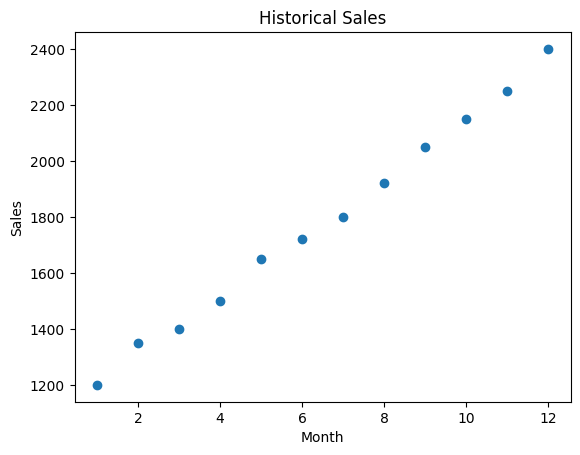

In [19]:
plt.scatter(data['Month'], data['Sales'])

plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Historical Sales")

plt.show()

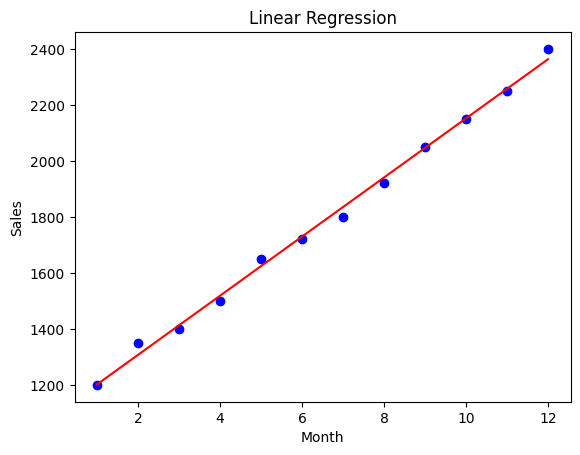

In [20]:
plt.scatter(data['Month'], data['Sales'], color='blue')

plt.plot(data['Month'], predictions,
         color='red')

plt.xlabel("Month")
plt.ylabel("Sales")

plt.title("Linear Regression")

plt.show()

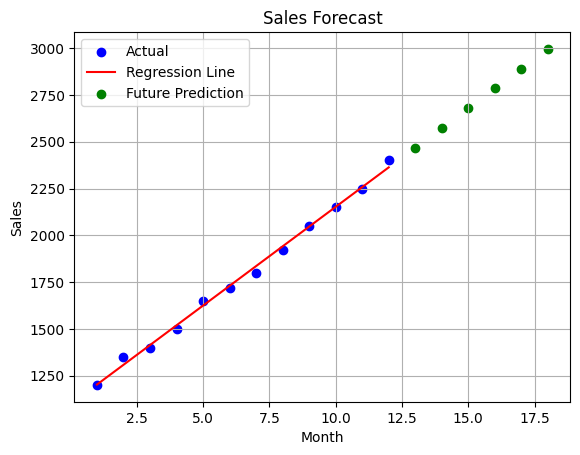

In [21]:
plt.scatter(data['Month'],
            data['Sales'],
            color='blue',
            label='Actual')

plt.plot(data['Month'],
         predictions,
         color='red',
         label='Regression Line')

plt.scatter(future_months,
            future_sales,
            color='green',
            label='Future Prediction')

plt.legend()

plt.xlabel("Month")
plt.ylabel("Sales")

plt.title("Sales Forecast")

plt.grid(True)

plt.show()

In [22]:
for month, sale in zip(future_months['Month'], future_sales):
    print("Month", month, "Predicted Sales =", round(sale,2))

Month 13 Predicted Sales = 2468.64
Month 14 Predicted Sales = 2574.2
Month 15 Predicted Sales = 2679.76
Month 16 Predicted Sales = 2785.31
Month 17 Predicted Sales = 2890.87
Month 18 Predicted Sales = 2996.43
